In [1]:
%load_ext cudf.pandas

In [5]:
def features_par_vol_gpu(df, capteurs, stats=("mean", "std", "max"),
                         phases=("montee", "croisiere", "descente")):
    """Même résultat que features_par_vol, sans MultiIndex (compatible cudf.pandas)."""
    morceaux = []
    for p in phases:
        groupe = df[df["phase"] == p].groupby(["unit", "cycle"])[capteurs]
        for s in stats:
            r = groupe.agg(s)                                   # un seul résumé → noms simples
            r.columns = [f"{c}_{s}_{p}" for c in r.columns]     # nom final directement
            morceaux.append(r)
    return pd.concat(morceaux, axis=1).reset_index()

debut = time.perf_counter()
feats_gpu = features_par_vol_gpu(d, CAPTEURS)
print(f"Avec cudf.pandas : {time.perf_counter() - debut:.2f} s | forme {feats_gpu.shape}")

Avec cudf.pandas : 0.77 s | forme (553, 128)


In [1]:
!nvidia-smi

Sun Oct  4 01:19:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import cudf
print("cuDF version :", cudf.__version__)

cuDF version : 26.06.00


In [3]:
!pip install -q --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git

from google.colab import drive
drive.mount("/content/drive")

import time
import pandas as pd
from aeroguard.normalisation import CAPTEURS
from aeroguard.features import ajouter_phase

DOSSIER = "/content/drive/MyDrive/aeroguard"
CHEMIN = f"{DOSSIER}/data/processed/ds01_dev.parquet"

def chrono(fonction, repetitions=3):
    """Lance la fonction plusieurs fois et garde le MEILLEUR temps (en secondes)."""
    temps = []
    for _ in range(repetitions):
        debut = time.perf_counter()
        fonction()
        temps.append(time.perf_counter() - debut)
    return min(temps)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive


In [4]:
t_cpu_lecture = chrono(lambda: pd.read_parquet(CHEMIN))
t_gpu_lecture = chrono(lambda: cudf.read_parquet(CHEMIN))
print(f"Lecture | CPU : {t_cpu_lecture:.2f} s | GPU : {t_gpu_lecture:.2f} s | gain ×{t_cpu_lecture/t_gpu_lecture:.1f}")

Lecture | CPU : 1.95 s | GPU : 0.41 s | gain ×4.7


In [5]:
dev = ajouter_phase(pd.read_parquet(CHEMIN))     # pandas, sur le CPU
debut = time.perf_counter()
gdev = cudf.from_pandas(dev)                     # copie vers le GPU
t_transfert = time.perf_counter() - debut
print(f"{len(dev):,} lignes | transfert CPU → GPU : {t_transfert:.2f} s")

4,906,636 lignes | transfert CPU → GPU : 0.37 s


In [6]:
def moyenne_par_vol(table):
    return table.groupby(["unit", "cycle"])[CAPTEURS].mean()

t_cpu_vol = chrono(lambda: moyenne_par_vol(dev))
t_gpu_vol = chrono(lambda: moyenne_par_vol(gdev))
print(f"Moyenne par vol | CPU : {t_cpu_vol:.3f} s | GPU : {t_gpu_vol:.3f} s | gain ×{t_cpu_vol/t_gpu_vol:.1f}")

Moyenne par vol | CPU : 0.407 s | GPU : 0.086 s | gain ×4.7


In [7]:
def resumes_par_phase(table):
    return table.groupby(["unit", "cycle", "phase"])[CAPTEURS].agg(["mean", "std", "max"])

t_cpu_feat = chrono(lambda: resumes_par_phase(dev))
t_gpu_feat = chrono(lambda: resumes_par_phase(gdev))
print(f"Features par phase | CPU : {t_cpu_feat:.3f} s | GPU : {t_gpu_feat:.3f} s | gain ×{t_cpu_feat/t_gpu_feat:.1f}")

/tmp/ipykernel_471/1989590854.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return table.groupby(["unit", "cycle", "phase"])[CAPTEURS].agg(["mean", "std", "max"])
/tmp/ipykernel_471/1989590854.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return table.groupby(["unit", "cycle", "phase"])[CAPTEURS].agg(["mean", "std", "max"])
/tmp/ipykernel_471/1989590854.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retu

Features par phase | CPU : 2.065 s | GPU : 0.106 s | gain ×19.5


In [8]:
cpu = moyenne_par_vol(dev).sort_index()
gpu = moyenne_par_vol(gdev).to_pandas().sort_index()
ecart_max = (cpu - gpu).abs().max().max()
print("Écart maximal CPU / GPU :", ecart_max)

Écart maximal CPU / GPU : 0.15318421182109887


In [9]:
feats = pd.read_parquet(f"{DOSSIER}/data/processed/ds01_dev_features.parquet")    # 553 lignes
gfeats = cudf.from_pandas(feats)
colonnes = [c for c in feats.columns if c.count("_") == 2]

t_cpu_petit = chrono(lambda: feats.groupby("unit")[colonnes].mean())
t_gpu_petit = chrono(lambda: gfeats.groupby("unit")[colonnes].mean())
print(f"553 lignes | CPU : {t_cpu_petit*1000:.1f} ms | GPU : {t_gpu_petit*1000:.1f} ms")

553 lignes | CPU : 1.2 ms | GPU : 12.2 ms


                tâche  CPU (s)  GPU (s)  gain
0     Lecture parquet    1.954    0.413   4.7
1     Moyenne par vol    0.407    0.086   4.7
2  Features par phase    2.065    0.106  19.5


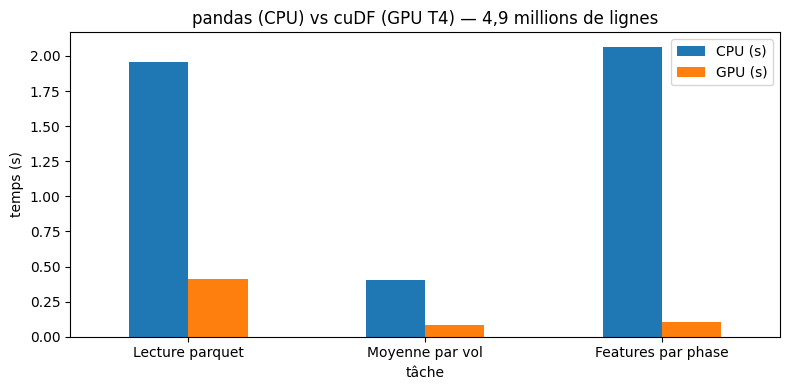

In [10]:
import matplotlib.pyplot as plt

recap = pd.DataFrame({
    "tâche": ["Lecture parquet", "Moyenne par vol", "Features par phase"],
    "CPU (s)": [t_cpu_lecture, t_cpu_vol, t_cpu_feat],
    "GPU (s)": [t_gpu_lecture, t_gpu_vol, t_gpu_feat],
})
recap["gain"] = (recap["CPU (s)"] / recap["GPU (s)"]).round(1)
print(recap.round(3))

ax = recap.plot.bar(x="tâche", y=["CPU (s)", "GPU (s)"], figsize=(8, 4), rot=0)
ax.set_ylabel("temps (s)")
ax.set_title("pandas (CPU) vs cuDF (GPU T4) — 4,9 millions de lignes")
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/19_cpu_vs_gpu.png", dpi=120)
plt.show()

recap.to_csv(f"{DOSSIER}/results/19_cpu_vs_gpu.csv", index=False)